# 1. Data
CIFAR10 is a subset of the 80 million tiny images dataset. They were collected by Alex Krizhevsky, Vinod Nair, and Geoffrey Hinton. The dataset is available at CIFAR-10 and CIFAR-100 datasets (toronto.edu) and can also be loaded directly from TensorFlow using tf.keras.datasets.cifar10.load_data.

**Problem Statement:**
Image classification is an important part of computer vision systems. Equipped with a digital camera and a single board computer (such as a Raspberry Pi), smart technology can capture an image, determine what is in the image using a classification model, and then take an action based on that information. As a warmup exercise to develop such technology, consider that you are tasked to classify images from the CIFAR10 dataset. You are to build your own CNN model for this, both from scratch and from an existing model via transfer learning and fine tuning.
## 1.1 Load Data
Load CIFAR10 dataset into training and testing, features and labels numpy arrays using cifar10.load_data. Using markdown, list the 10 classes. 

In [21]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import layers, models
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.applications import VGG16
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [22]:
(features_train, label_train), (features_test, label_test) = cifar10.load_data()

In [23]:
# Printing the unique labels in the training set
set(label_train.flatten())

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

### Classes obtained
We obtained the 10 classes to be the integer numbers from 0 to 9 (a total of 10 classes).

## 1.2 Bar Plot Checking for Classes Distribution
Create a bar plot using seaborn.barplot of the number of elements in each category of the entire dataset. Use markdown to comment on how well balanced the dataset is.

Text(0.5, 1.0, 'Distribution of CIFAR-10 Classes')

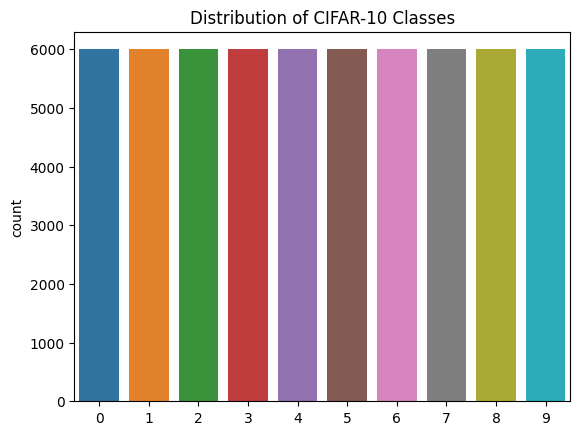

In [ ]:
entire_dataset = list(label_train.flatten()) + list(label_test.flatten())
sns.countplot(x=entire_dataset)
plt.title('Distribution of CIFAR-10 Classes')

The dataset is perfectly balanced. Each one of the classes has exactly 6000 instances on it for a total of 60000 instances.

## 1.3 Splitting the dataset
Use sklearn.model_selection.train_test_split to split the test set into test and validation sets choosing appropriate proportions. 

In [25]:
label_train = label_train.flatten()
label_test = label_test.flatten()

features_val, features_test, label_val, label_test = train_test_split(features_test,
                                                                    label_test,
                                                                    test_size=0.5,
                                                                    random_state=42)

print(f"Training set shape: {features_train.shape}, {label_train.shape}")
print(f"Validation set shape: {features_val.shape}, {label_val.shape}")
print(f"Test set shape: {features_test.shape}, {label_test.shape}")

Training set shape: (50000, 32, 32, 3), (50000,)
Validation set shape: (5000, 32, 32, 3), (5000,)
Test set shape: (5000, 32, 32, 3), (5000,)


## 1.4 Data Generators
Create train, test, and validation data generators using tensorflow.keras.preprocessing.image.ImageDataGenerator; each should scale the data by dividing by 255, and the training generator should also use data augmentation. 

In [26]:
train_img_gen = ImageDataGenerator(
    rescale=1./255,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    rotation_range=20,          # random rotations (degrees)
    zoom_range=0.2,             # random zoom in/out
    shear_range=0.15,           # shear transformations
    brightness_range=[0.7, 1.3],# random brightness adjustments
    fill_mode='nearest',        # how to fill missing pixels after transforms
    channel_shift_range=20.0,   # random channel intensity shifts
    vertical_flip=False,
)
val_img_gen = ImageDataGenerator(rescale=1./255)
test_img_gen = ImageDataGenerator(rescale=1./255)

batch_size= 16
img_height = 32
img_width = 32

Running the flow functions on the CIFAR10 data

In [27]:
train_data_gen = train_img_gen.flow(features_train, label_train, batch_size=batch_size)
val_data_gen = val_img_gen.flow(features_val, label_val, batch_size=batch_size)
test_data_gen = test_img_gen.flow(features_test, label_test, batch_size=batch_size)

# 2. Modeling


## 2.1 CNN construction
Use tf.keras.Sequential to create a convolutional neural network. Use at least two convolution layers and at least two pooling layers. Choose an activation function for each layer, and make sure the input and output dimensions are appropriate for the data. Print a summary of the model using tf.summary.

In [9]:
np.random.seed(8)
tf.random.set_seed(8)

model = tf.keras.Sequential([
    layers.Conv2D(64, 3, activation='relu', input_shape=(img_height, img_width ,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 64)        1792      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 15, 15, 64)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 128)       73856     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 6, 6, 128)        0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 4608)              0         
                                                                 
 dense (Dense)               (None, 128)               5

## 2.2 Model Compiling
Compile the model with a choice of optimizer, sparse_categorical_crossentropy for the loss function, and set the metrics argument equal to ['accuracy'].

In [10]:
optimizer = tf.keras.optimizers.Adam(0.001)
model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

## 2.3 Model Training
Train the model using the train and validation data generators; record the training accuracy. Experiment with different architectures other hyperparameters to improve upon the results.

In [11]:
model.fit(
    train_data_gen,
    steps_per_epoch=len(features_train) // batch_size,
    epochs=10,
    validation_data=val_data_gen,
    validation_steps=len(features_val) // batch_size
)

Epoch 1/10
3125/3125 [==============================] - 54s 17ms/step - loss: 1.5584 - accuracy: 0.4390 - val_loss: 1.2397 - val_accuracy: 0.5485
Epoch 2/10
3125/3125 [==============================] - 55s 18ms/step - loss: 1.2800 - accuracy: 0.5459 - val_loss: 1.0265 - val_accuracy: 0.6454
Epoch 3/10
3125/3125 [==============================] - 57s 18ms/step - loss: 1.1821 - accuracy: 0.5789 - val_loss: 1.0049 - val_accuracy: 0.6398
Epoch 4/10
3125/3125 [==============================] - 64s 20ms/step - loss: 1.1189 - accuracy: 0.6045 - val_loss: 0.9370 - val_accuracy: 0.6611
Epoch 5/10
3125/3125 [==============================] - 66s 21ms/step - loss: 1.0787 - accuracy: 0.6192 - val_loss: 0.8997 - val_accuracy: 0.6855
Epoch 6/10
3125/3125 [==============================] - 66s 21ms/step - loss: 1.0424 - accuracy: 0.6376 - val_loss: 0.8790 - val_accuracy: 0.6961
Epoch 7/10
3125/3125 [==============================] - 67s 21ms/step - loss: 1.0142 - accuracy: 0.6429 - val_loss: 0.9066 -

## 2.4 Loading an Existant Model
Start a new model by loading one of the models from tensorflow.keras.applications along with the pretrained weights; don't include the top layer. Check if your model comes with preprocess_input function and be sure to use that properly with your data before training. Describe the model you chose using markdown and explain why you think it will work well for this use case.

In [28]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

np.random.seed(8)
tf.random.set_seed(8)

# Upscale CIFAR-10 images to a larger size (better for pretrained convnets)
img_height = 96
img_width = 96
batch_size = 64

# Resize numpy arrays (tf.image.resize returns float32) to match input shape
features_train_resized = tf.image.resize(features_train, [img_height, img_width]).numpy()
features_val_resized = tf.image.resize(features_val, [img_height, img_width]).numpy()
features_test_resized = tf.image.resize(features_test, [img_height, img_width]).numpy()

# Stronger augmentation and correct preprocessing for MobileNetV2 (maps to [-1,1])
train_img_gen = ImageDataGenerator(preprocessing_function=preprocess_input,
                                   rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
                                   shear_range=0.15, zoom_range=0.15, horizontal_flip=True, fill_mode='nearest')
val_img_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_img_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Create generators from resized numpy arrays
train_data_gen = train_img_gen.flow(features_train_resized, label_train, batch_size=batch_size)
val_data_gen = val_img_gen.flow(features_val_resized, label_val, batch_size=batch_size)
test_data_gen = test_img_gen.flow(features_test_resized, label_test, batch_size=batch_size)

In [29]:
base_model = MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)
# Freeze all base layers initially
base_model.trainable = False

9406464/9406464 [==============================] - 0s 0us/step


### Model Description and Justification
We are using MobileNetV2 as our model.

**Description:**
MobileNetv2 is lightweight and fast convulational neural network architecture designed for image classification. Instead of expanding channels after convolution, it expands first and then compresses, improving efficiency.

**Justification:**
Its pretrained ImageNet features transfer effectively to CIFAR‑10 classes, allowing the model to achieve high accuracy without requiring heavy computational resources.
Additionally, we also tested another model called VGG16 which was way more complex, but not more efficient, and actually it didn't do a better job compared to the base model. Due to current computing caabilities, `MobileNetV2` was the best option to try.

## 2.5 Adding top layers
Add on a new top layer with appropriate hyperparameter choices. Choose a number of layers to freeze. Print a summary of the model.

In [30]:
# Create new model with custom top layers
inputs = layers.Input(shape=(img_height, img_width, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation='softmax')(x)
transfer_model = models.Model(inputs, outputs)

## 2.6 Compiling the model
Compile the model with a choice of optimizer and loss function, and the set the metrics argument equal to ['accuracy'].

In [31]:

transfer_model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

transfer_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 96, 96, 3)]       0         


                                                                 
 mobilenetv2_1.00_96 (Functi  (None, 3, 3, 1280)       2257984   
 onal)                                                           
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization (BatchN  (None, 1280)             5120      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense_2 (Dense)             (None, 256)               327936    
                                                                 
 batch_normalization_1 (Batc  (None, 256)              1024      
 hNormaliz

## 2.7 Train the model
Train the model using the train and validation data generators; record the training accuracy. Experiment with different architectures, different numbers of frozen layers, and other hyperparameters to improve upon the results.

In [32]:
history_head = transfer_model.fit(
    train_data_gen,
    epochs=30,
    steps_per_epoch=20,
    validation_data=val_data_gen,
    validation_steps=10
)


Epoch 1/30
20/20 [==============================] - 17s 591ms/step - loss: 1.9048 - accuracy: 0.4062 - val_loss: 0.9801 - val_accuracy: 0.6703
Epoch 2/30
20/20 [==============================] - 10s 482ms/step - loss: 1.1114 - accuracy: 0.6508 - val_loss: 0.7780 - val_accuracy: 0.7641
Epoch 3/30
20/20 [==============================] - 10s 491ms/step - loss: 0.9927 - accuracy: 0.6781 - val_loss: 0.7317 - val_accuracy: 0.7781
Epoch 4/30
20/20 [==============================] - 10s 476ms/step - loss: 0.9452 - accuracy: 0.7000 - val_loss: 0.6722 - val_accuracy: 0.7797
Epoch 5/30
20/20 [==============================] - 10s 500ms/step - loss: 0.9250 - accuracy: 0.6938 - val_loss: 0.6294 - val_accuracy: 0.7828
Epoch 6/30
20/20 [==============================] - 10s 506ms/step - loss: 0.8548 - accuracy: 0.7070 - val_loss: 0.6178 - val_accuracy: 0.7922
Epoch 7/30
20/20 [==============================] - 10s 489ms/step - loss: 0.8912 - accuracy: 0.6992 - val_loss: 0.5626 - val_accuracy: 0.8094

### Explanation of Fine Tuning
- We unfroze the top 40 layers of the base model, and these add upon the ones we added on our own as the top layers of the model.
- Now, in this training iteration, we compile and fit the model again on using the image generators but the latests layers of the model weights are being slightly modified in order to improve performance, as well as using a smaller learning rate for this process (`1e-5`).
- This fine tuning remarkably improved the model's performance.

In [33]:
# Phase 2: fine-tune — unfreeze top layers of the base model and train with a low LR
base_model.trainable = True
# Freeze most layers, only leave the top block(s) trainable to avoid overfitting quickly
for layer in base_model.layers[:-40]:
    layer.trainable = False

transfer_model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

history_fine = transfer_model.fit(
    train_data_gen,
    epochs=20,
    steps_per_epoch=20,
    validation_data=val_data_gen,
    validation_steps=10
)

Epoch 1/20
20/20 [==============================] - 20s 647ms/step - loss: 0.6887 - accuracy: 0.7625 - val_loss: 0.4887 - val_accuracy: 0.8313
Epoch 2/20
20/20 [==============================] - 11s 533ms/step - loss: 0.6304 - accuracy: 0.7742 - val_loss: 0.4830 - val_accuracy: 0.8375
Epoch 3/20
20/20 [==============================] - 10s 502ms/step - loss: 0.6928 - accuracy: 0.7586 - val_loss: 0.4941 - val_accuracy: 0.8219
Epoch 4/20
20/20 [==============================] - 11s 538ms/step - loss: 0.6181 - accuracy: 0.7867 - val_loss: 0.5742 - val_accuracy: 0.8172
Epoch 5/20
20/20 [==============================] - 11s 538ms/step - loss: 0.6129 - accuracy: 0.7883 - val_loss: 0.4828 - val_accuracy: 0.8484
Epoch 6/20
20/20 [==============================] - 11s 562ms/step - loss: 0.6537 - accuracy: 0.7625 - val_loss: 0.5394 - val_accuracy: 0.8219
Epoch 7/20
20/20 [==============================] - 11s 522ms/step - loss: 0.5940 - accuracy: 0.7914 - val_loss: 0.4795 - val_accuracy: 0.8406

# 3. Conclusion
## 3.a Training and Validation Accuracies
Find the training and validation accuracies, and validation confusion matrix for both the custom CNN and transfer learning models. Present the results for both neatly. Use markdown to compare them and select the best model.

### Base model CNN Analysis

In [34]:
final_train_acc_base = 0.7059
final_val_acc_base = 0.7133

print(f"Final Training Accuracy:   {final_train_acc_base:.4f}")
print(f"Final Validation Accuracy: {final_val_acc_base:.4f}")

Final Training Accuracy:   0.7059
Final Validation Accuracy: 0.7133


<Figure size 1000x800 with 0 Axes>

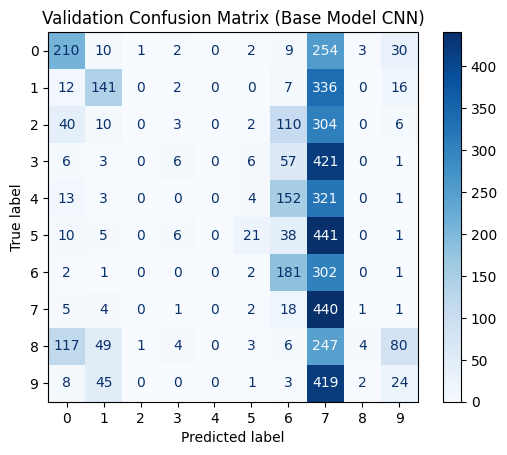

In [35]:
y_true_base = label_val
y_prob_base = model.predict(features_val.astype("float32") / 255.0, batch_size=batch_size, verbose=0)
y_pred_base = np.argmax(y_prob_base, axis=1)

cm = confusion_matrix(y_true_base, y_pred_base)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Validation Confusion Matrix (Base Model CNN)")
plt.show()

### Custom CNN Analysis

In [36]:
final_train_acc = history_fine.history["accuracy"][-1]
final_val_acc = history_fine.history["val_accuracy"][-1]

print(f"Final Training Accuracy:   {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")

Final Training Accuracy:   0.7961
Final Validation Accuracy: 0.8547


<Figure size 1000x800 with 0 Axes>

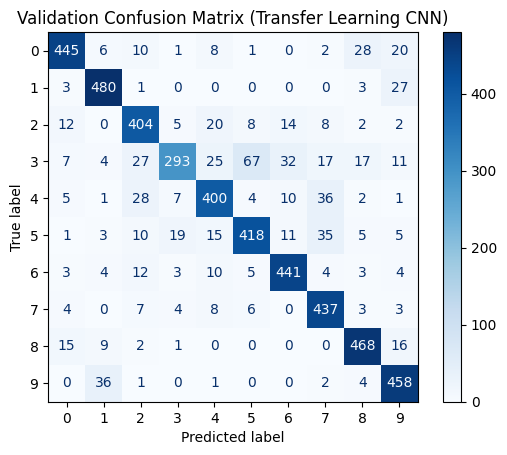

In [37]:

y_true = label_val
x_val = preprocess_input(features_val_resized.astype("float32"))
y_prob = transfer_model.predict(x_val, batch_size=batch_size, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Validation Confusion Matrix (Transfer Learning CNN)")
plt.show()

### Comparision and Model Selection
- Overall, the transfer learning model had better accuracy scores for both training and validation datasets, with aprox `79%` training and `85%` validation accuracy. If we compare it to our base model accuracies, the training accuracy was around `70%`, and `71%` for our validation dataset and therefore the best model is the **transfer model**.
- Based on the confusion matrices results, we can see that the transfer model TP are closer to 500 per class (our validation dataset is balanced) in general. That means the transfer learning model will be more accurate for real world testing and implementations when predicting new objects.

### Selected Model: Transfer Learning Model (MobileNetV2)

## 3.b Testing Accuracy
Find the testing accuracy and confusion matrix of only the best model.

<Figure size 1000x800 with 0 Axes>

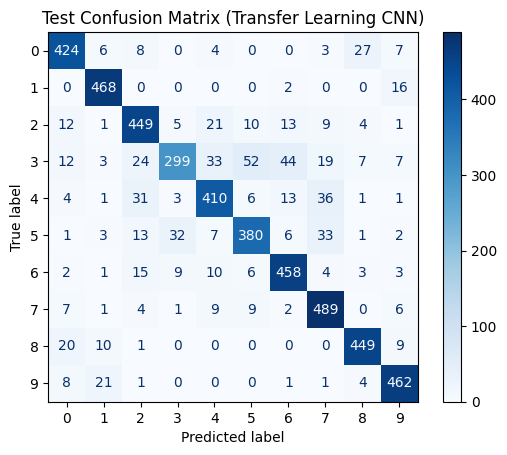

In [38]:
y_true = label_test
x_test = preprocess_input(features_test_resized.astype("float32"))
y_prob = transfer_model.predict(x_test, batch_size=batch_size, verbose=0)
y_pred = np.argmax(y_prob, axis=1) # Taking the highest probability class as the prediction

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Test Confusion Matrix (Transfer Learning CNN)")
plt.show()

In [39]:
_ , test_acc = transfer_model.evaluate(
    x_test,
    label_test,
    batch_size=batch_size,
    verbose=1
)

print(f"Test Accuracy: {test_acc:.4f}")

79/79 [==============================] - 29s 360ms/step - loss: 0.4229 - accuracy: 0.8576
Test Accuracy: 0.8576


## 3.c Prediction With External Images
Use the model to make predictions on at least three other images from one of the 10 classes

In [41]:
class_names = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

images_list = ['airplane4.png', 'horse6.png', 'truck5.png']

for img_name in images_list:
    print(f"\nPredicting for {img_name}...")
    img = tf.keras.utils.load_img(r"images\{}".format(img_name), target_size=(96, 96))
    x = tf.keras.utils.img_to_array(img).astype("float32")
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    probs = transfer_model.predict(x, verbose=0)[0]
    top3 = np.argsort(probs)[-3:][::-1]

    for i in top3:
        print(f"{class_names[i]}: {probs[i]*100:.2f}%")


Predicting for airplane4.png...
airplane: 65.76%
truck: 22.58%
ship: 6.94%

Predicting for horse6.png...
horse: 96.23%
deer: 3.62%
bird: 0.07%

Predicting for truck5.png...
truck: 90.78%
horse: 4.24%
dog: 2.42%


## 3.d Model Performance Conclusions
Use markdown to comment on how well the model works to make predictions for this use case.

- On our testing phase, we tried different images for the model to predict a class, and the model was not good for some of them. Althought we have 85% testing accuracy in our validation dataset, the model was not perfect with external images and turned out to misclassify a couple of them.
- The model is transparent in the way it is showing to the user how confident it is in its predictions, even showing other possible options that could have been predicted as well to the user and leaving the final decision for a human.
- This model has still a lot of room for improvement in terms of performance. A higher number of epochs as well as increasing our number of images would improve accuracy and generalization for real-world implementations.
- Based on the confusion matrix results, the model has slightly better at predicting some of the classes than the others.
